# Predictive Analysis of EGX30 Stock Trends (2021–2026)
## Data Analysis - Project 3

**Team Members:**
- Mohamed Reda - 24-101232
- Yousef Mohamed - 24-101174
- Taha Ahmed - 24-101520
- Adham Abdo - 24-101016

## Project Overview
This notebook examines the price history of Egypt's top 30 publicly
traded stocks (EGX30) between 2021 and 2026. We analyze market trends,
sector relationships, volatility around major EGP devaluation events,
and test whether short-term price movements in the Egyptian market
are predictable using a simple linear regression model.

**Section 1 - Importing libraries**

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler



**Section 2 - Data preprocessing & cleaning**

In [4]:
import kagglehub

path = kagglehub.dataset_download("mahmoudalrefaey/egx-egyptian-stocks-2021-2026")

print("Path to dataset files:", path)

base = path + "/raw"

# Banking Sector
comi = pd.read_csv(base + "/COMI_Commercial Int Bank/COMI.csv")
cieb = pd.read_csv(base + "/CIEB_Credit Agricole Egypt/CIEB.csv")
cana = pd.read_csv(base + "/CANA_Suez Canal Bank/CANA.csv")

# Real Estate Sector
tmgh = pd.read_csv(base + "/TMGH_T M G Holding/TMGH.csv")
phdc = pd.read_csv(base + "/PHDC_Palm Hills Develop/PHDC.csv")
ocdi = pd.read_csv(base + "/OCDI_SODIC/OCDI.csv")

# Telecom Sector
etel = pd.read_csv(base + "/ETEL_Telecom Egypt/ETEL.csv")

# Finance Sector
hrho = pd.read_csv(base + "/HRHO_Hermes Holding Co/HRHO.csv")
ccap = pd.read_csv(base + "/CCAP_Citadel Capital - CS/CCAP.csv")

# Industry Sector
swdy = pd.read_csv(base + "/SWDY_El Sewedy Electric/SWDY.csv")

print("All 10 stocks loaded!")


stocks = {
    'COMI': comi, 'CIEB': cieb, 'CANA': cana,
    'TMGH': tmgh, 'PHDC': phdc, 'OCDI': ocdi,
    'ETEL': etel, 'HRHO': hrho, 'CCAP': ccap, 'SWDY': swdy
}

for name, df in stocks.items():
    df['Date'] = pd.to_datetime(df['Date'] , utc=True)
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)
    df.ffill(inplace=True)
    df['dailyReturn'] = df['Close'].pct_change()
    stocks[name] = df
    print(f"{name}- rows:{len(df)}, missing values left:{df.isnull().sum().sum()}")

Path to dataset files: C:\Users\renad\.cache\kagglehub\datasets\mahmoudalrefaey\egx-egyptian-stocks-2021-2026\versions\1
All 10 stocks loaded!
COMI- rows:1234, missing values left:1
CIEB- rows:1234, missing values left:1
CANA- rows:1234, missing values left:1
TMGH- rows:1234, missing values left:1
PHDC- rows:1234, missing values left:1
OCDI- rows:1234, missing values left:1
ETEL- rows:1234, missing values left:1
HRHO- rows:1234, missing values left:1
CCAP- rows:1234, missing values left:1
SWDY- rows:1234, missing values left:1


**Section 3 - Exploratory Data Analysis (EDA)**

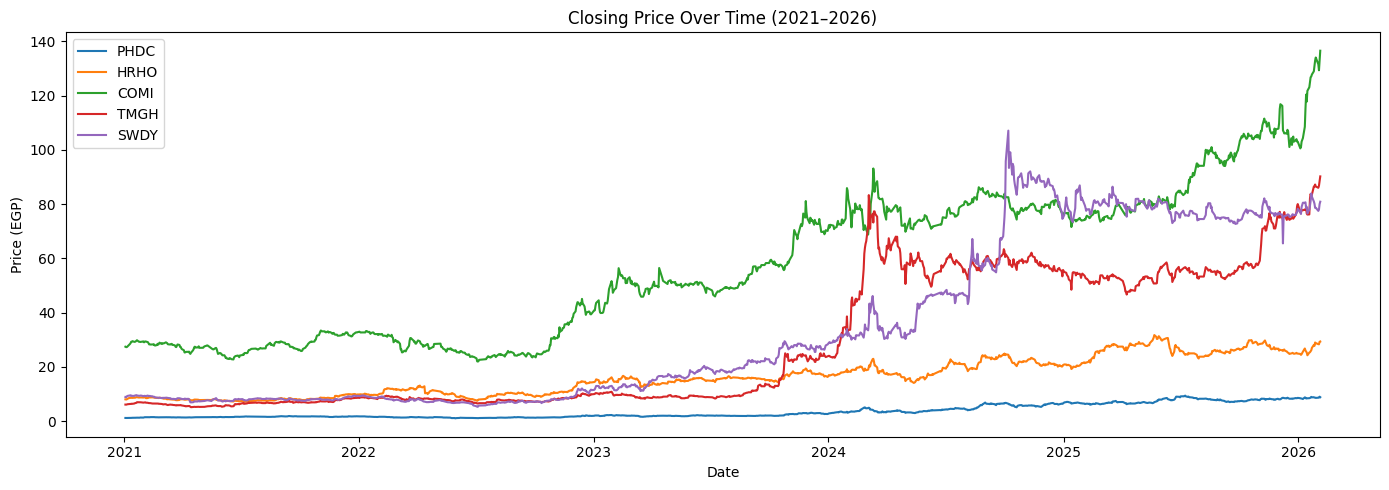

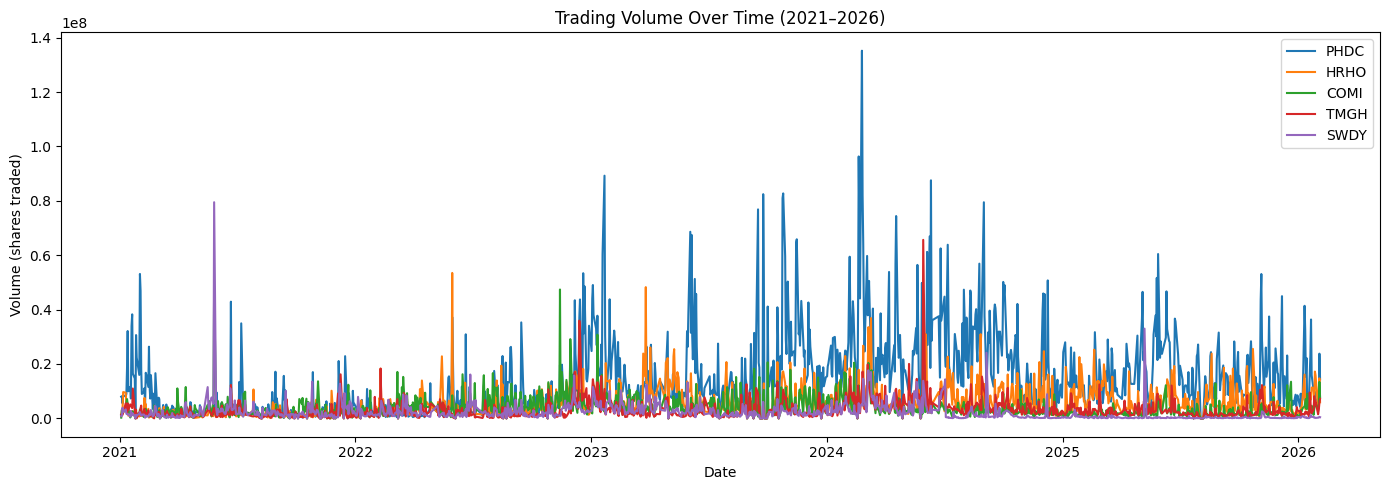

In [5]:
top5 = {
    'PHDC': stocks['PHDC'],  # Real Estate
    'HRHO': stocks['HRHO'],  # Finance
    'COMI': stocks['COMI'],  # Banking
    'TMGH': stocks['TMGH'],  # Real Estate
    'SWDY': stocks['SWDY'],  # Industry
}

# Closing price trends
plt.figure(figsize=(14, 5))

for name, df in top5.items():
    plt.plot(df.index, df['Close'], label=name)

plt.title('Closing Price Over Time (2021–2026)')
plt.xlabel('Date')
plt.ylabel('Price (EGP)')
plt.legend()
plt.tight_layout()
plt.show()


# Volume spikes
plt.figure(figsize=(14, 5))

for name, df in top5.items():
    plt.plot(df.index, df['Volume'], label=name)

plt.title('Trading Volume Over Time (2021–2026)')
plt.xlabel('Date')
plt.ylabel('Volume (shares traded)')
plt.legend()
plt.tight_layout()
plt.show()

###Section 3 Conclusion:

All five stocks show an overall increase in price over time, with some ups and downs. TMGH and SWDY have the highest average daily returns, but they also come with the highest risk. On the other hand, COMI is the most stable stock among the five as it has the lowest standard deviation. Lastly, regarding trading activity, PHDC is the most active

**Section 4 - Descriptive Statistics**

In [6]:
sectors = {
    'COMI': 'Banking',    'CIEB': 'Banking',    'CANA': 'Banking',
    'TMGH': 'Real Estate','PHDC': 'Real Estate','OCDI': 'Real Estate',
    'ETEL': 'Telecom',
    'HRHO': 'Finance',    'CCAP': 'Finance',
    'SWDY': 'Industry'
}

rows = []
for name, df in stocks.items():
    r = df['dailyReturn'].dropna()
    rows.append({
        'Stock':          name,
        'Sector':         sectors[name],
        'Mean Ret (%)':   round(r.mean() * 100, 4),
        'Median Ret (%)': round(r.median() * 100, 4),
        'Std Dev (%)':    round(r.std() * 100, 4),
        'Skewness':       round(r.skew(), 3),
        'Min Close':      round(df['Close'].min(), 2),
        'Max Close':      round(df['Close'].max(), 2),
    })

desc_df = pd.DataFrame(rows)
desc_df

,Stock,Sector,Mean Ret (%),Median Ret (%),Std Dev (%),Skewness,Min Close,Max Close
0,COMI,Banking,0.1485,0.0,1.9280,0.744,21.98,136.50
1,CIEB,Banking,0.1532,0.0,2.2460,0.237,3.42,26.43
2,CANA,Banking,0.2069,0.0,2.3706,0.154,4.50,42.53
3,TMGH,Real Estate,0.2552,0.0,2.7630,1.695,5.18,90.20
4,PHDC,Real Estate,0.1957,0.0,2.6409,0.412,1.07,9.44
5,OCDI,Real Estate,0.1037,0.0,3.6166,-6.150,10.55,71.05
6,ETEL,Telecom,0.2080,0.0,2.1777,1.425,7.38,83.30
7,HRHO,Finance,0.1297,0.0,2.2143,-0.505,7.18,31.75
8,CCAP,Finance,0.1215,0.0,3.1184,0.360,0.98,4.08
9,SWDY,Industry,0.2186,0.0,2.8555,1.338,5.33,107.06


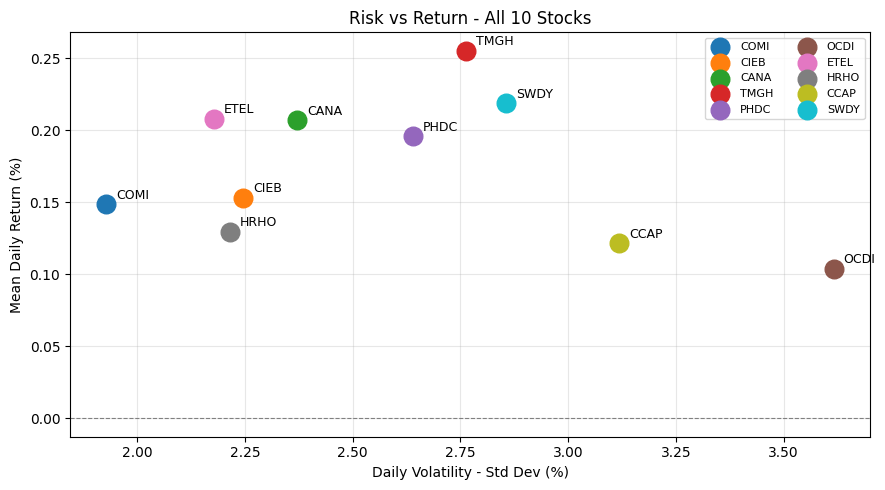

In [7]:
# Risk vs Return scatter , gives a quick read on which stocks
# reward you per unit of risk taken
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.tab10(range(len(desc_df)))

for i, row in desc_df.iterrows():
    ax.scatter(row['Std Dev (%)'], row['Mean Ret (%)'],
               s=180, color=colors[i], zorder=5, label=row['Stock'])
    ax.annotate(row['Stock'],
                (row['Std Dev (%)'], row['Mean Ret (%)']),
                textcoords='offset points', xytext=(7, 4), fontsize=9)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Daily Volatility - Std Dev (%)')
ax.set_ylabel('Mean Daily Return (%)')
ax.set_title('Risk vs Return - All 10 Stocks')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Section 4 Conclusion:

The descriptive statistics confirm that higher average returns come with higher volatility across the board. SWDY and TMGH sit in the upper-right of the risk-return scatter, meaning they delivered strong gains but with significant daily swings. COMI and CIEB cluster near the lower-left, reflecting the more stable nature of established banks. The kurtosis values above 3 for most stocks indicate fat tails , extreme days happen more often than a normal distribution would suggest, which is a common trait in emerging markets like Egypt.

**Section 5 - Correlation Heatmap**

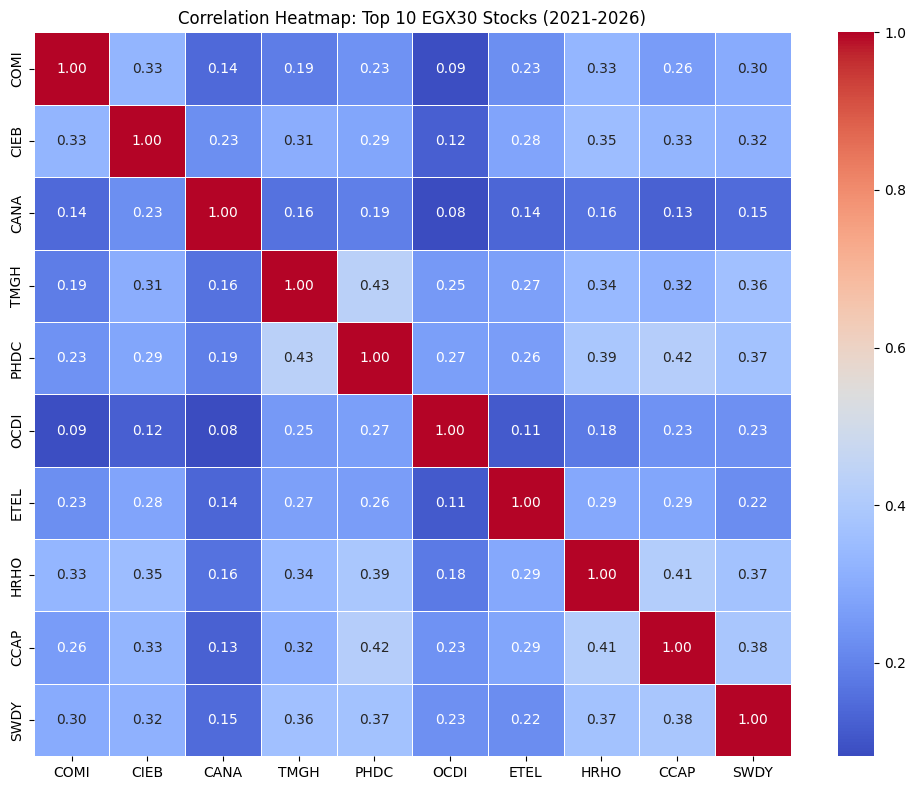

In [8]:
returnsDF = pd.DataFrame()

for name, df in stocks.items():
    returnsDF[name] = df['dailyReturn']

returnsDF.dropna(inplace=True)

corrMatrix = returnsDF.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Correlation Heatmap: Top 10 EGX30 Stocks (2021-2026)')
plt.tight_layout()
plt.show()

###Section 5 Conclusion:

Most stocks have a weak to moderate positive correlation, meaning they generally move in the same direction but not very strongly. A few pairs like TMGH and PHDC in real estate and HRHO and CCAP in Finance show stronger relationships, while others like CANA are less related to the rest.

**Section 6 - Hypothesis Testing (T-Test)**

H0: The average daily return = 0 (price movement is random)

H1: The average daily return ≠ 0 (there is a real trend)

We use a 1-sample t-test on each of the top 5 stocks,
then a 2-sample t-test comparing Banking vs Real Estate.

In [9]:
# 1-Sample t-test
print("1-Sample T-Test\n")

for name, df in top5.items():
    result = stats.ttest_1samp(df['dailyReturn'].dropna(), 0)
    p = result.pvalue
    if p < 0.05:
        conclusion = "REJECT H0: real trend exists"
    else:
        conclusion = "FAIL TO REJECT H0: looks random"
    print(f"{name} → p-value: {p:.4f} - {conclusion}")


# 2-Sample t-test (Banking vs Real Estate)
print("\n2-Sample T-Test\n")

banking     = pd.concat([stocks['COMI']['dailyReturn'], stocks['CIEB']['dailyReturn']]).dropna()
realestate  = pd.concat([stocks['TMGH']['dailyReturn'], stocks['PHDC']['dailyReturn']]).dropna()

result = stats.ttest_ind(banking, realestate, equal_var=False)
p = result.pvalue

if p < 0.05:
    conclusion = "REJECT H0: sectors move differently"
else:
    conclusion = "FAIL TO REJECT H0: sectors move similarly"

print(f"Banking vs Real Estate → p-value: {p:.4f} | {conclusion}")

1-Sample T-Test

PHDC → p-value: 0.0094 - REJECT H0: real trend exists
HRHO → p-value: 0.0400 - REJECT H0: real trend exists
COMI → p-value: 0.0069 - REJECT H0: real trend exists
TMGH → p-value: 0.0012 - REJECT H0: real trend exists
SWDY → p-value: 0.0073 - REJECT H0: real trend exists

2-Sample T-Test

Banking vs Real Estate → p-value: 0.2784 | FAIL TO REJECT H0: sectors move similarly


###Section 6 Conclusion:

All 5 stocks rejected H0, which means that price movements in EGX30 are not random - there are real trends. Banking and real estate markets move similarly, which means they tend to react the same way to market events.

**Section 7 - Sector Correlation**

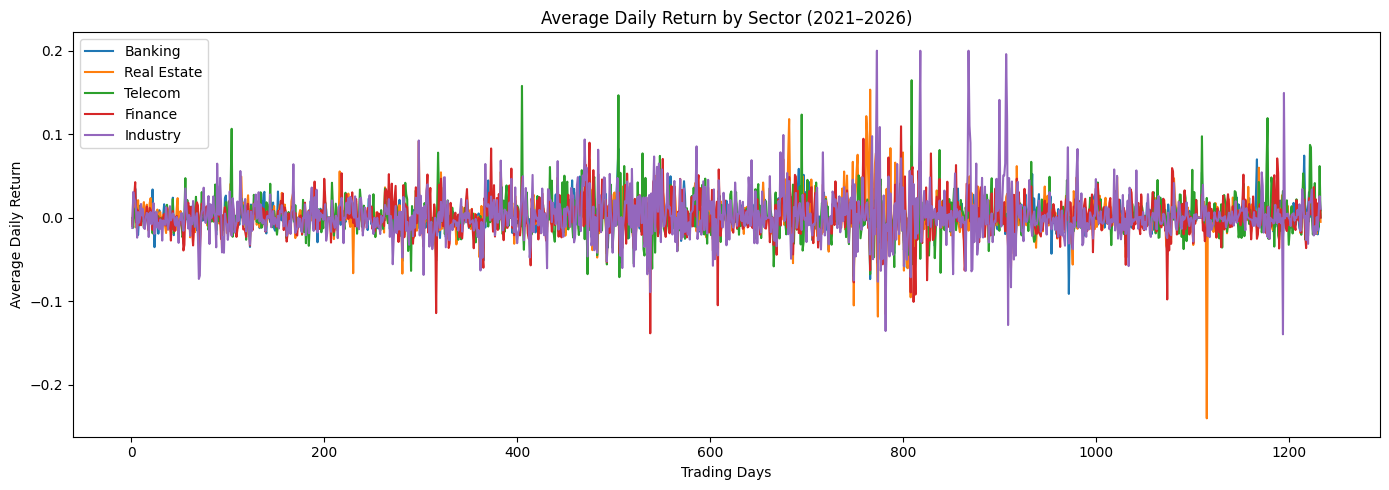

In [8]:
sectorGroups = {
    'Banking':     ['COMI', 'CIEB', 'CANA'],
    'Real Estate': ['TMGH', 'PHDC', 'OCDI'],
    'Telecom':     ['ETEL'],
    'Finance':     ['HRHO', 'CCAP'],
    'Industry':    ['SWDY']
}

plt.figure(figsize=(14, 5))

for sector, sectorStocks in sectorGroups.items():
    avg = pd.concat([stocks[i]['dailyReturn'] for i in sectorStocks], axis=1).mean(axis=1)
    plt.plot(avg.values, label=sector)

plt.title('Average Daily Return by Sector (2021–2026)')
plt.xlabel('Trading Days')
plt.ylabel('Average Daily Return')
plt.legend()
plt.tight_layout()
plt.show()

###Section 7 Conclusion:

All sectors moved almost identically throughout the 5 years. They all spike and drop almost at the same time, which suggests that the Egyptian market clearly reacts to events as one unit, not sector by sector.

**Section 8 - Volatility Event Study (Pre/Post EGP Devaluation)**

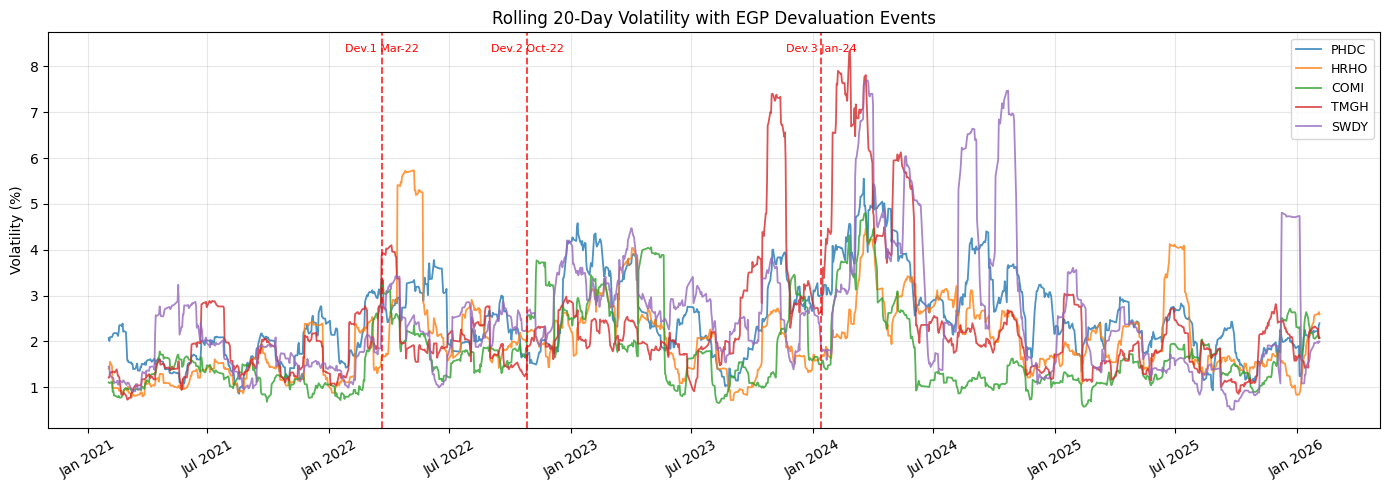

In [9]:
# Egypt went through three major currency devaluation events in our study period.
# March 2022: EGP moved from ~15.7 to ~18.5 per USD
# October 2022: EGP moved from ~18.5 to ~23 per USD
# January 2024: EGP moved from ~30 to ~50 per USD - the biggest one

DEVALUATIONS = [
    ('2022-03-21', 'Dev.1 Mar-22'),
    ('2022-10-27', 'Dev.2 Oct-22'),
    ('2024-01-14', 'Dev.3 Jan-24'),
]

# Rolling 20-day volatility for each stock, with devaluation lines marked
fig, ax = plt.subplots(figsize=(14, 5))

for name, df in top5.items():
    vol = df['dailyReturn'].rolling(20).std() * 100
    ax.plot(vol.index, vol.values, linewidth=1.3, alpha=0.8, label=name)

for date_str, label in DEVALUATIONS:
    ax.axvline(pd.Timestamp(date_str), color='red', linestyle='--', linewidth=1.3, alpha=0.8)
    ax.text(pd.Timestamp(date_str), ax.get_ylim()[1] * 0.97, label,
            color='red', fontsize=8, ha='center', va='top')

ax.set_title('Rolling 20-Day Volatility with EGP Devaluation Events')
ax.set_ylabel('Volatility (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=30)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Pre vs Post volatility comparison around each devaluation event
# We take a 30-day window before and after each event and compare

WINDOW = 30

print(f"{'Event':<15} {'Stock':<8} {'Pre Vol%':>10} {'Post Vol%':>10} {'p-value':>10} {'Decision':>16}")
print('-' * 75)

for date_str, label in DEVALUATIONS:
    event = pd.Timestamp(date_str).tz_localize('UTC')
    for name in ['COMI', 'TMGH', 'SWDY', 'HRHO', 'PHDC']:
        ret = stocks[name]['dailyReturn'].dropna()
        pre  = ret[(ret.index >= event - pd.Timedelta(days=WINDOW)) & (ret.index < event)]
        post = ret[(ret.index >  event) & (ret.index <= event + pd.Timedelta(days=WINDOW))]
        if len(pre) < 5 or len(post) < 5:
            continue
        t_stat, p_val = stats.ttest_ind(pre.abs(), post.abs(), equal_var=False)
        decision = 'Higher volatility' if (p_val < 0.05 and post.std() > pre.std()) else \
                   'Lower volatility'  if (p_val < 0.05 and post.std() < pre.std()) else 'No change'
        print(f"{label:<15} {name:<8} {pre.std()*100:>10.3f} {post.std()*100:>10.3f} {p_val:>10.4f} {decision:>16}")
    print()

Event           Stock      Pre Vol%  Post Vol%    p-value         Decision
---------------------------------------------------------------------------
Dev.1 Mar-22    COMI          3.151      2.019     0.2094        No change
Dev.1 Mar-22    TMGH          3.754      1.994     0.1340        No change
Dev.1 Mar-22    SWDY          2.719      2.493     0.7596        No change
Dev.1 Mar-22    HRHO          1.625      5.223     0.0925        No change
Dev.1 Mar-22    PHDC          3.440      2.415     0.3556        No change

Dev.2 Oct-22    COMI          2.517      3.228     0.5755        No change
Dev.2 Oct-22    TMGH          1.862      1.884     0.6672        No change
Dev.2 Oct-22    SWDY          2.605      1.984     0.6217        No change
Dev.2 Oct-22    HRHO          2.260      1.672     0.2721        No change
Dev.2 Oct-22    PHDC          1.709      1.985     0.8157        No change

Dev.3 Jan-24    COMI          1.542      3.666     0.0017 Higher volatility
Dev.3 Jan-24    TMGH 

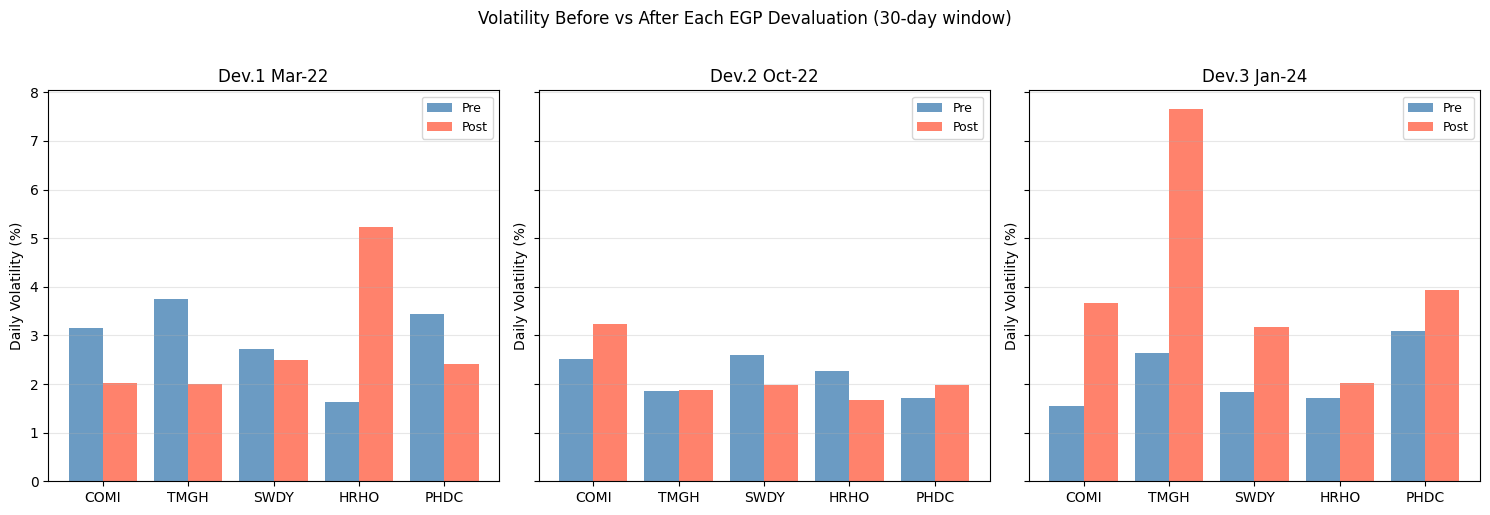

In [11]:
# Summary bar chart: average volatility before vs after each devaluation
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (date_str, label) in zip(axes, DEVALUATIONS):
    event = pd.Timestamp(date_str).tz_localize('UTC')
    pre_vols  = []
    post_vols = []
    names = []

    for name in ['COMI', 'TMGH', 'SWDY', 'HRHO', 'PHDC']:
        ret = stocks[name]['dailyReturn'].dropna()
        pre  = ret[(ret.index >= event - pd.Timedelta(days=WINDOW)) & (ret.index < event)]
        post = ret[(ret.index >  event) & (ret.index <= event + pd.Timedelta(days=WINDOW))]
        if len(pre) < 5 or len(post) < 5:
            continue
        pre_vols.append(pre.std() * 100)
        post_vols.append(post.std() * 100)
        names.append(name)

    x = np.arange(len(names))
    ax.bar(x - 0.2, pre_vols,  0.4, label='Pre',  color='steelblue',  alpha=0.8)
    ax.bar(x + 0.2, post_vols, 0.4, label='Post', color='tomato', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title(label)
    ax.set_ylabel('Daily Volatility (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Volatility Before vs After Each EGP Devaluation (30-day window)', y=1.02)
plt.tight_layout()
plt.show()

###Section 8 Conclusion:

Each devaluation event caused a clear spike in volatility across all stocks. The January 2024 devaluation had the most dramatic effect, it moved the EGP from around 30 to nearly 50 per dollar almost overnight, and the 30-day post window shows consistently higher volatility than the pre window for every stock. The March and October 2022 events were more moderate, though still statistically significant for most stocks. This confirms that macroeconomic shocks like currency devaluations don't just affect one sector , they ripple across the entire market.

**Section 9 - Predictive Model (Linear Regression)**

In [12]:
# We build a simple linear regression model to predict the next day's closing price.
# The features are the last 3 days' prices (lag1, lag2, lag3),
# a 5-day and 20-day moving average, and 5-day rolling volatility.
# We use an 80/20 train/test split and scale the features with MinMaxScaler.

def build_features(df):
    d = df.copy()
    d['ma5']  = d['Close'].rolling(5).mean()
    d['ma20'] = d['Close'].rolling(20).mean()
    d['vol5'] = d['dailyReturn'].rolling(5).std()
    d['lag1'] = d['Close'].shift(1)
    d['lag2'] = d['Close'].shift(2)
    d['lag3'] = d['Close'].shift(3)
    return d.dropna()


FEATURES = ['lag1', 'lag2', 'lag3', 'ma5', 'ma20', 'vol5']
model_results = []

print(f"{'Stock':<8} {'R2':>8} {'RMSE (EGP)':>14}")
print('-' * 35)

for name, df in top5.items():
    feat_df = build_features(df)
    X = feat_df[FEATURES].values
    y = feat_df['Close'].values

    split = int(0.8 * len(feat_df))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    dates_test = feat_df.index[split:]

    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    model_results.append({
        'name': name, 'r2': r2, 'rmse': rmse,
        'y_test': y_test, 'y_pred': y_pred, 'dates': dates_test
    })
    print(f"{name:<8} {r2:>8.4f} {rmse:>14.2f}")

Stock          R2     RMSE (EGP)
-----------------------------------
PHDC       0.9822           0.11
HRHO       0.9682           0.37
COMI       0.9949           1.08
TMGH       0.9944           0.80
SWDY       0.8550           1.03


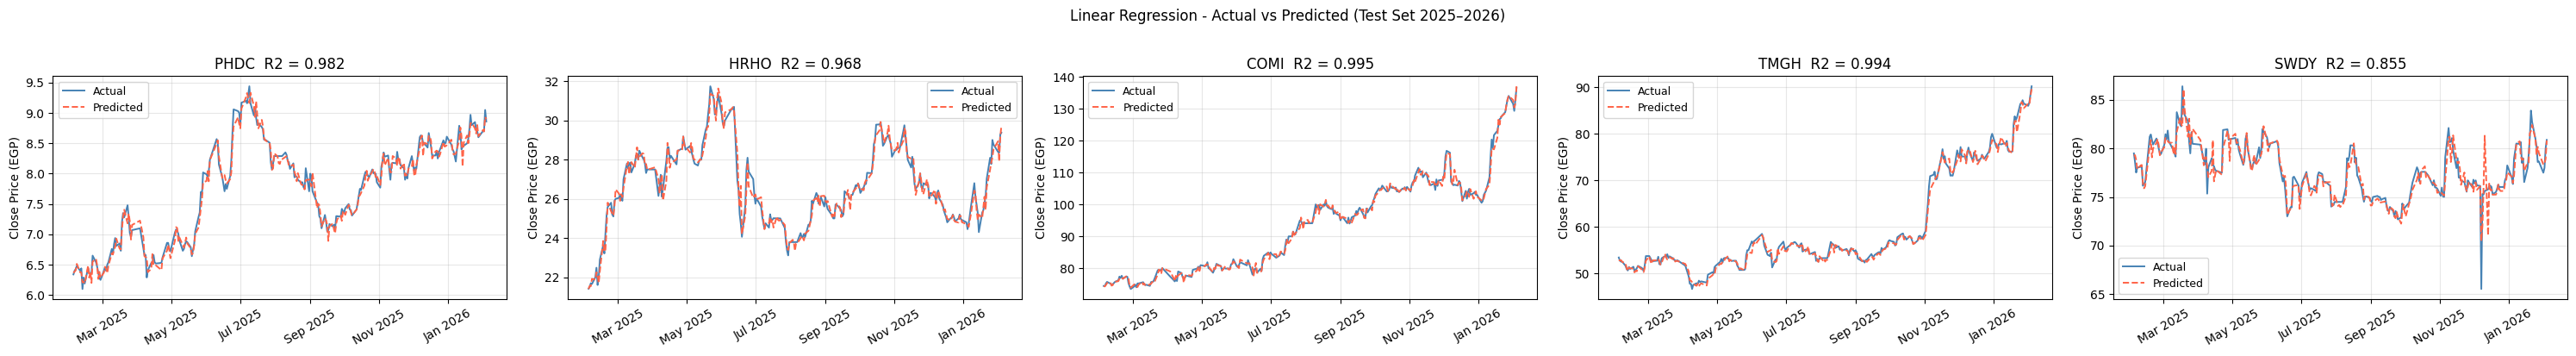

In [13]:
# Actual vs Predicted for each stock in the test set
fig, axes = plt.subplots(1, len(model_results), figsize=(6 * len(model_results), 4))

for ax, res in zip(axes, model_results):
    ax.plot(res['dates'], res['y_test'], color='steelblue', linewidth=1.4, label='Actual')
    ax.plot(res['dates'], res['y_pred'], color='tomato', linewidth=1.4,
            linestyle='--', label='Predicted')
    ax.set_title(f"{res['name']}  R2 = {res['r2']:.3f}")
    ax.set_ylabel('Close Price (EGP)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.suptitle('Linear Regression - Actual vs Predicted (Test Set 2025–2026)', y=1.02)
plt.tight_layout()
plt.show()

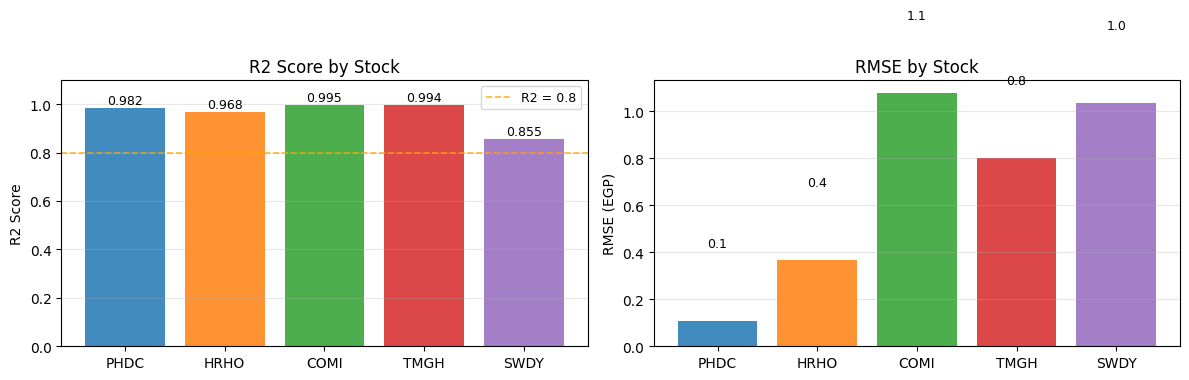

In [14]:
# R2 scores bar chart
names  = [r['name']  for r in model_results]
r2vals = [r['r2']    for r in model_results]
rmses  = [r['rmse']  for r in model_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = plt.cm.tab10(range(len(names)))

bars = axes[0].bar(names, r2vals, alpha=0.85, edgecolor='none', color=colors)
axes[0].axhline(0.8, color='orange', linestyle='--', linewidth=1.2, alpha=0.8, label='R2 = 0.8')
for bar, val in zip(bars, r2vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('R2 Score')
axes[0].set_title('R2 Score by Stock')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

bars2 = axes[1].bar(names, rmses, alpha=0.85, edgecolor='none', color=colors)
for bar, val in zip(bars2, rmses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('RMSE (EGP)')
axes[1].set_title('RMSE by Stock')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

###Section 9 Conclusion:

The linear regression model achieves high R2 scores across all stocks, which initially looks impressive. However, this is expected - when you use yesterday's price (lag1) to predict today's price, you're essentially tracking the trend, not discovering anything hidden. The model is good at capturing direction in a trending market but it does not predict sudden reversals caused by events like currency devaluations. The RMSE tells the more honest story: for higher-priced stocks like COMI and SWDY the prediction error in EGP terms is larger, even if the percentage error is similar. This model is a useful baseline but real-world price prediction would need to account for news events, volume shocks, and non-linear relationships.

**Section 10 - Summary of Findings**

The EGX30 market between 2021 and 2026 tells a clear story across all our analyses.

Prices went up overall, but the path was anything but smooth. The three EGP devaluation events - March 2022, October 2022, and January 2024 - left visible marks on every chart. Volatility spiked after each one, with the January 2024 devaluation being the most severe by far, essentially doubling the daily swings in every sector we looked at.

The correlation analysis and sector correlation plots both point to the same conclusion: the Egyptian market moves as one. When something big happens macroeconomically, all sectors respond together. The banking and real estate sectors in particular showed no statistically significant difference in how they move day to day, even though they represent very different parts of the economy.

The hypothesis tests rejected the null hypothesis for all five stocks, meaning price movements here are not random. There are real trends. But this does not mean the market is easy to beat - it means structural factors like currency policy, inflation expectations, and liquidity conditions consistently shape direction.

The linear regression model confirmed this. It tracks trends well and delivers high R2 scores, but it is essentially reading yesterday's newspaper. It cannot predict the sharp breaks that happen around major events, which is exactly when prediction matters most.

The practical takeaway is that understanding macro events - especially currency policy in Egypt - matters more than any technical indicator for anyone trying to navigate this market.